In [3]:
import json
from pathlib import Path

from model_ranking import (
    plot_performance_vs_transfer_metric_multi_target,
    to_target_transfer_correlations,
    correlation_table,
    load_transfer_metric_results,
)

In [4]:
performance_path = "/g/kreshuk/talks/consistency_results/patch_segmentation/mitochondria/transfer_results/ccfv/transfer_performance_F1_scores.json"
with open(performance_path, "r") as f:
    performance_scores = json.load(f)["performance_scores"]

Loaded Transfer metric results from: /g/kreshuk/talks/consistency_results/patch_segmentation/mitochondria/transfer_results/ccfv/transfer_CCFV_scores.json
Processing: CCFV
Number of targets: 4
  Target 1: EPFL
  Target 2: Hmito
  Target 3: Rmito
  Target 4: VNC


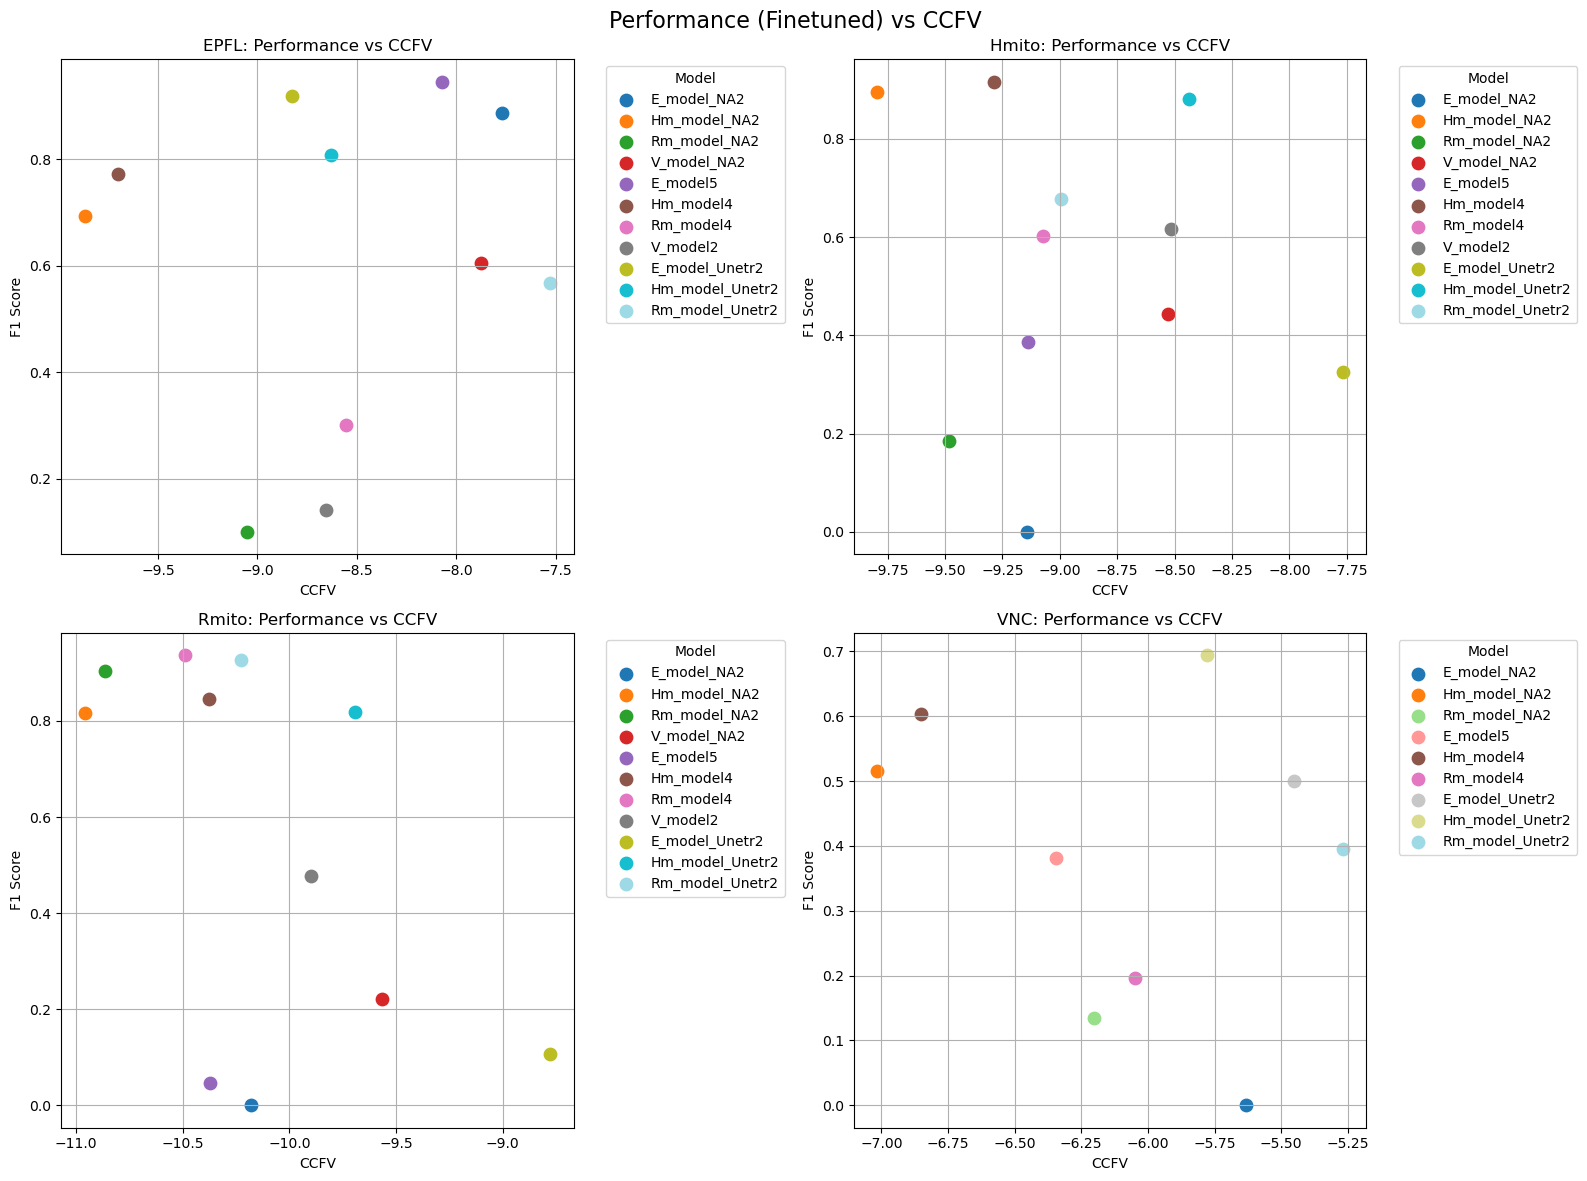

                kt  kt pval  s rho  s rho pval    pr  pr pval
Task targets                                                 
Mito EPFL     0.13     0.65   0.12        0.71  0.10     0.76
     Hmito    0.02     1.00  -0.06        0.80 -0.12     0.73
     Rmito   -0.35     0.18  -0.49        0.16 -0.52     0.10
     VNC     -0.17     0.60  -0.22        0.60 -0.24     0.54


In [5]:
base_path = "/g/kreshuk/talks/consistency_results/patch_segmentation/mitochondria/transfer_results/ccfv"

file_name = f"transfer_CCFV_scores.json"
consistency_path = Path(base_path) / file_name
results = load_transfer_metric_results(consistency_path)
consistency_scores = results["transfer_scores"]
targets = list(consistency_scores.keys())
plot_performance_vs_transfer_metric_multi_target(
    performance_scores=performance_scores,
    transfer_scores=consistency_scores,
    transfer_metric=f"CCFV",
    finetuned=True,
)
KT_scores, SP_scores, PE_scores = to_target_transfer_correlations(
    targets=targets,
    transfer_metric_per_target=consistency_scores,
    performance_per_target=performance_scores,
    )
correlation_df = correlation_table(KT_scores, SP_scores, PE_scores, targets=targets)
print(correlation_df)